# 09 Indirect Peak Prediction From Meter Readings

Evaluate the indirect peak-prediction approach:

1. Train regression models to predict hourly `meter_reading`.
2. Predict all 24 hours for every complete, non-flat validation building-day.
3. Select the hour with the largest predicted meter reading.
4. Compare that predicted peak with the actual peak hour.

This notebook uses the selected Random Forest and tuned Gradient Boosting regression configurations from the tabular workflow. It compares their derived peaks with the direct peak-hour Random Forest classifier and the fixed 14:00 baseline. The chronological test dataset remains untouched.

## Setup

In [1]:
from gc import collect
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TRAIN_SAMPLE_ROWS = 500_000

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
modeling_dir = project_root / "data" / "processed" / "modeling"
reports_dir = project_root / "reports"
figures_dir = project_root / "figures"
reports_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

## Load Training Data and Complete Validation Days

In [2]:
def representative_sample(
    frame: pd.DataFrame,
    sample_rows: int,
    random_state: int,
) -> pd.DataFrame:
    if len(frame) <= sample_rows:
        return frame.copy()

    sample_fraction = sample_rows / len(frame)
    sampled = frame.groupby(
        ["site_id", "month", "primary_use"],
        observed=True,
        group_keys=False,
    ).sample(frac=sample_fraction, random_state=random_state)

    if len(sampled) > sample_rows:
        sampled = sampled.sample(n=sample_rows, random_state=random_state)
    elif len(sampled) < sample_rows:
        remaining = frame.loc[~frame.index.isin(sampled.index)]
        additional = remaining.sample(
            n=sample_rows - len(sampled),
            random_state=random_state,
        )
        sampled = pd.concat([sampled, additional], ignore_index=False)

    return sampled.sort_values("timestamp").reset_index(drop=True)


train_pool = pd.read_parquet(modeling_dir / "model_train.parquet")
validation_pool = pd.read_parquet(modeling_dir / "model_validation.parquet")
train_data = representative_sample(
    train_pool,
    TRAIN_SAMPLE_ROWS,
    RANDOM_STATE,
)

validation_pool["date"] = validation_pool["timestamp"].dt.normalize()
validation_day_summary = (
    validation_pool.groupby(["building_id", "date"], observed=True)
    .agg(
        hourly_records=("hour", "count"),
        unique_hours=("hour", "nunique"),
        unique_readings=("meter_reading", "nunique"),
    )
    .reset_index()
)
eligible_validation_days = validation_day_summary[
    (validation_day_summary["hourly_records"] == 24)
    & (validation_day_summary["unique_hours"] == 24)
    & (validation_day_summary["unique_readings"] > 1)
][["building_id", "date"]]

validation_data = validation_pool.merge(
    eligible_validation_days,
    on=["building_id", "date"],
    how="inner",
    validate="many_to_one",
).sort_values(["building_id", "date", "timestamp"]).reset_index(drop=True)

del train_pool, validation_pool
collect()

pd.Series(
    {
        "training_rows": len(train_data),
        "eligible_validation_building_days": len(eligible_validation_days),
        "validation_hourly_rows": len(validation_data),
        "rows_per_validation_day": (
            len(validation_data) / len(eligible_validation_days)
        ),
    }
)

training_rows                         500000.0
eligible_validation_building_days      70390.0
validation_hourly_rows               1689360.0
rows_per_validation_day                   24.0
dtype: float64

## Use the Existing Meter-Reading Feature Set

In [3]:
def add_modeling_features(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["log_square_feet"] = np.log1p(result["square_feet"])
    result["building_age"] = (2016 - result["year_built"]).clip(lower=0)
    return result


train_data = add_modeling_features(train_data)
validation_data = add_modeling_features(validation_data)

numeric_features = [
    "log_square_feet",
    "building_age",
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
]
categorical_features = ["site_id", "primary_use"]
feature_columns = numeric_features + categorical_features
target_column = "meter_reading"

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            sparse_output=False,
                            dtype=np.float32,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

X_train = preprocessor.fit_transform(train_data[feature_columns]).astype(
    "float32"
)
X_validation = preprocessor.transform(
    validation_data[feature_columns]
).astype("float32")
y_train = train_data[target_column].to_numpy(dtype="float64")
y_validation = validation_data[target_column].to_numpy(dtype="float64")

X_train.shape, X_validation.shape

((500000, 45), (1689360, 45))

## Train the Selected Meter-Reading Regressors

In [4]:
regression_models = {
    "Indirect Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        max_features=1.0,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Indirect Gradient Boosting": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=10,
        subsample=0.8,
        loss="squared_error",
        random_state=RANDOM_STATE,
    ),
}

regression_metric_rows = []
hourly_predictions = {}

for model_name, model in regression_models.items():
    print(f"Training {model_name}...")
    start = perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = perf_counter() - start
    predictions = np.clip(
        model.predict(X_validation),
        a_min=0,
        a_max=None,
    )
    hourly_predictions[model_name] = predictions
    regression_metric_rows.append(
        {
            "model": model_name,
            "rmse": np.sqrt(mean_squared_error(y_validation, predictions)),
            "mae": mean_absolute_error(y_validation, predictions),
            "r2": r2_score(y_validation, predictions),
            "rmsle": np.sqrt(
                mean_squared_log_error(y_validation, predictions)
            ),
            "fit_seconds": fit_seconds,
        }
    )

hourly_regression_metrics = pd.DataFrame(regression_metric_rows).sort_values(
    "rmse"
)
hourly_regression_metrics

Training Indirect Random Forest...
Training Indirect Gradient Boosting...


,model,rmse,mae,r2,rmsle,fit_seconds
0,Indirect Random Forest,167.667629,30.036755,0.803896,0.419247,82.335978
1,Indirect Gradient Boosting,194.402859,79.319411,0.736371,0.931070,214.419168


## Derive Daily Peak Hours

In [5]:
peak_frame = validation_data[
    ["building_id", "date", "hour", "meter_reading"]
].copy()

actual_peak_indices = peak_frame.groupby(
    ["building_id", "date"],
    observed=True,
)["meter_reading"].idxmax()
actual_peaks = peak_frame.loc[
    actual_peak_indices,
    ["building_id", "date", "hour"],
].rename(columns={"hour": "actual_peak_hour"})


def calculate_peak_metrics(
    method: str,
    actual_hours: np.ndarray,
    predicted_hours: np.ndarray,
) -> dict:
    absolute_difference = np.abs(actual_hours - predicted_hours)
    circular_error = np.minimum(
        absolute_difference,
        24 - absolute_difference,
    )
    return {
        "method": method,
        "evaluated_building_days": len(actual_hours),
        "exact_peak_accuracy": (circular_error == 0).mean(),
        "within_1_hour_accuracy": (circular_error <= 1).mean(),
        "within_2_hours_accuracy": (circular_error <= 2).mean(),
        "mean_peak_hour_error": circular_error.mean(),
        "median_peak_hour_error": np.median(circular_error),
    }


peak_metric_rows = []
actual_hours = actual_peaks["actual_peak_hour"].to_numpy()

baseline_hours = np.full_like(actual_hours, fill_value=14)
peak_metric_rows.append(
    calculate_peak_metrics(
        "Always predict 14:00",
        actual_hours,
        baseline_hours,
    )
)

for model_name, predictions in hourly_predictions.items():
    model_peak_frame = peak_frame[
        ["building_id", "date", "hour"]
    ].copy()
    model_peak_frame["predicted_meter_reading"] = predictions
    predicted_peak_indices = model_peak_frame.groupby(
        ["building_id", "date"],
        observed=True,
    )["predicted_meter_reading"].idxmax()
    predicted_peaks = model_peak_frame.loc[
        predicted_peak_indices,
        ["building_id", "date", "hour"],
    ].rename(columns={"hour": "predicted_peak_hour"})

    comparison = actual_peaks.merge(
        predicted_peaks,
        on=["building_id", "date"],
        how="inner",
        validate="one_to_one",
    )
    peak_metric_rows.append(
        calculate_peak_metrics(
            model_name,
            comparison["actual_peak_hour"].to_numpy(),
            comparison["predicted_peak_hour"].to_numpy(),
        )
    )

indirect_peak_metrics = pd.DataFrame(peak_metric_rows).sort_values(
    ["within_1_hour_accuracy", "exact_peak_accuracy"],
    ascending=False,
)
indirect_peak_metrics.to_csv(
    reports_dir / "indirect_peak_validation_metrics.csv",
    index=False,
)

indirect_peak_metrics

,method,evaluated_building_days,exact_peak_accuracy,within_1_hour_accuracy,within_2_hours_accuracy,mean_peak_hour_error,median_peak_hour_error
1,Indirect Random Forest,70390,0.116167,0.324705,0.491078,3.435545,3.0
0,Always predict 14:00,70390,0.100483,0.288209,0.437662,3.775210,3.0
2,Indirect Gradient Boosting,70390,0.065506,0.193749,0.321111,4.568632,4.0


## Compare Direct and Indirect Peak Prediction

In [6]:
direct_metrics = pd.read_csv(
    reports_dir / "peak_hour_validation_metrics.csv"
)
direct_random_forest = direct_metrics[
    direct_metrics["model"] == "Random Forest"
].iloc[0]

combined_rows = indirect_peak_metrics.rename(
    columns={"method": "model"}
).to_dict("records")
combined_rows.append(
    {
        "model": "Direct Random Forest Classifier",
        "evaluated_building_days": len(actual_peaks),
        "exact_peak_accuracy": direct_random_forest[
            "exact_peak_accuracy"
        ],
        "within_1_hour_accuracy": direct_random_forest[
            "within_1_hour_accuracy"
        ],
        "within_2_hours_accuracy": direct_random_forest[
            "within_2_hours_accuracy"
        ],
        "mean_peak_hour_error": direct_random_forest[
            "mean_peak_hour_error"
        ],
        "median_peak_hour_error": direct_random_forest[
            "median_peak_hour_error"
        ],
    }
)

direct_vs_indirect = pd.DataFrame(combined_rows).sort_values(
    ["within_1_hour_accuracy", "exact_peak_accuracy"],
    ascending=False,
).reset_index(drop=True)
direct_vs_indirect.to_csv(
    reports_dir / "direct_vs_indirect_peak_metrics.csv",
    index=False,
)

direct_vs_indirect

,model,evaluated_building_days,exact_peak_accuracy,within_1_hour_accuracy,within_2_hours_accuracy,mean_peak_hour_error,median_peak_hour_error
0,Direct Random Forest Classifier,70390,0.212317,0.474073,0.632917,2.607501,2.0
1,Indirect Random Forest,70390,0.116167,0.324705,0.491078,3.435545,3.0
2,Always predict 14:00,70390,0.100483,0.288209,0.437662,3.775210,3.0
3,Indirect Gradient Boosting,70390,0.065506,0.193749,0.321111,4.568632,4.0


## Direct and Indirect Comparison Visual

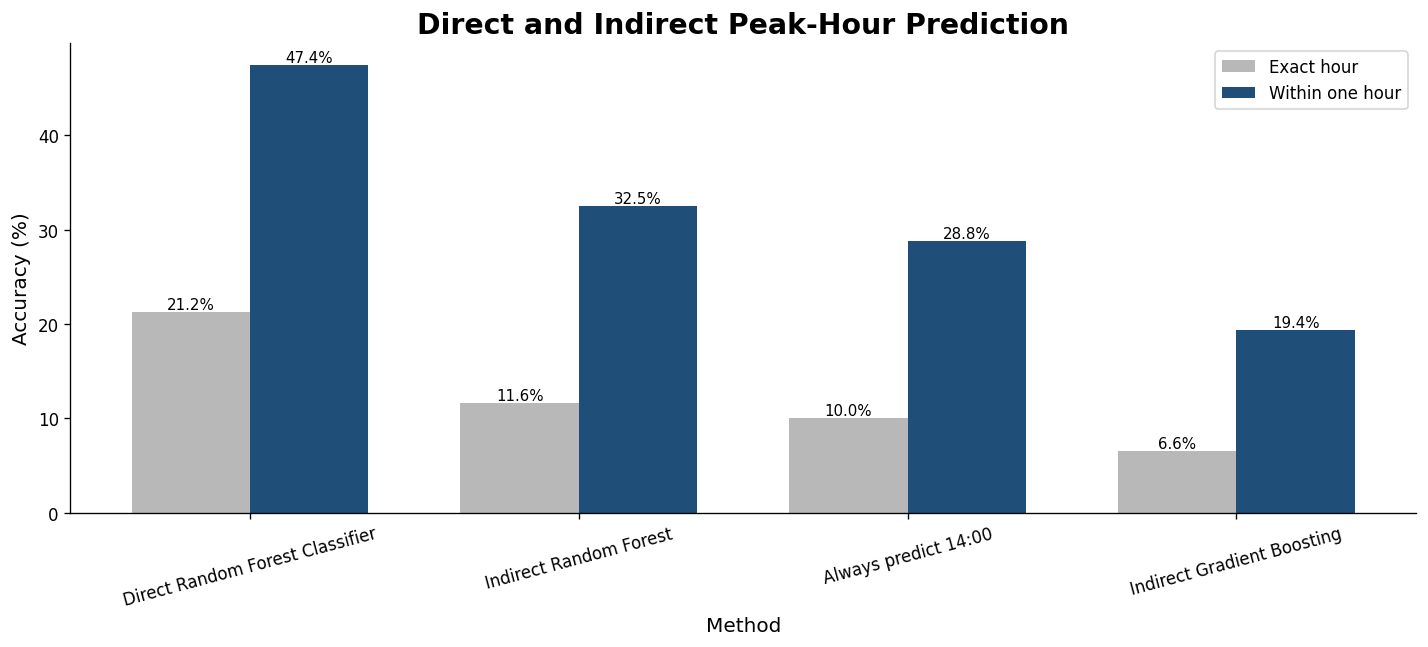

In [7]:
plot_data = direct_vs_indirect.copy()
x_positions = np.arange(len(plot_data))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(12, 5.5), dpi=120)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

exact_bars = ax.bar(
    x_positions - bar_width / 2,
    plot_data["exact_peak_accuracy"] * 100,
    width=bar_width,
    color="#b8b8b8",
    label="Exact hour",
)
within_bars = ax.bar(
    x_positions + bar_width / 2,
    plot_data["within_1_hour_accuracy"] * 100,
    width=bar_width,
    color="#1f4e79",
    label="Within one hour",
)

ax.set_title("Direct and Indirect Peak-Hour Prediction", fontsize=17, weight="bold")
ax.set_xlabel("Method", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_xticks(x_positions)
ax.set_xticklabels(plot_data["model"], rotation=15)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

for bars in [exact_bars, within_bars]:
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
fig.savefig(
    figures_dir / "direct_vs_indirect_peak_prediction.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Interpretation Rule

The regression approach is useful only if selecting the largest predicted hourly meter reading produces reliable peak timing. Compare it with both the direct classifier and the fixed 14:00 rule using identical validation building-days. Current-hour weather observations are treated as proxies for forecast weather. Keep the chronological test period untouched until the preferred approach is selected.